In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np  
import scienceplots
plt.style.use(['science','no-latex'])
matplotlib.rcParams['pdf.fonttype'] = 42

In [2]:
import os
os.chdir('..')
os.getcwd()

'/home/ubuntu/work/saved_data/tree_height_uncertainty_quantification'

In [3]:
quantiles = [0.5, 0.05, 0.1, 0.15,0.2,0.25,0.75, 0.8,0.85,0.9,0.95]
quantiles_sorted = sorted(quantiles)
target_col = 'gedi_data'
displayed_model_names = ['Lang et. al.', 'Ours']
model_names = ['lang', 'ours']

## Test that GEDI data are in correct order

In [6]:
df1 = pd.read_pickle('results_dataframes/results_{model_name}.pkl'.format(model_name=model_names[0]))
df2 = pd.read_pickle('results_dataframes/results_{model_name}.pkl'.format(model_name=model_names[1]))
(df1['gedi_data'].values == df2['gedi_data'].values).all()  # Check that GEDI data are the same in both dataframes

True

## Calculate Pearson Correlation between prediction\gedi data and PIW

In [7]:
df1['uncertainty'] = df1['quantile_0.9'] - df1['quantile_0.1']
df2['uncertainty'] = df2['quantile_0.9'] - df2['quantile_0.1']

In [8]:
# For df1, columns are objects, so convert to float first
uncertainty_df1 = pd.to_numeric(df1['uncertainty'], errors='coerce')
quantile_05_df1 = pd.to_numeric(df1['quantile_0.5'], errors='coerce')
pearson_df1 = uncertainty_df1.corr(quantile_05_df1, method='pearson')

# For df2, columns are already float
pearson_df2 = df2['uncertainty'].corr(df2['quantile_0.5'], method='pearson')

print(f"Pearson correlation for Prediction: {displayed_model_names[0]}: {pearson_df1:.4f}")
print(f"Pearson correlation for Prediction: {displayed_model_names[1]}: {pearson_df2:.4f}")

Pearson correlation for Prediction: Lang et. al.: 0.8522
Pearson correlation for Prediction: Ours: 0.7351


In [10]:
# For df1, columns are objects, so convert to float first
uncertainty_df1 = pd.to_numeric(df1['uncertainty'], errors='coerce')
quantile_05_df1 = pd.to_numeric(df1['gedi_data'], errors='coerce')
pearson_df1 = uncertainty_df1.corr(quantile_05_df1, method='pearson')

# For df2, columns are already float
pearson_df2 = df2['uncertainty'].corr(df2['gedi_data'], method='pearson')

print(f"Pearson correlation for Labels: {displayed_model_names[0]}: {pearson_df1:.4f}")
print(f"Pearson correlation for Labels: {displayed_model_names[1]}: {pearson_df2:.4f}")

Pearson correlation for Labels: Lang et. al.: 0.5948
Pearson correlation for Labels: Ours: 0.6604


## Point-Estimator Results

In [11]:
def create_one_point_estimator_table(model_names,target_col = 'gedi_data', displayed_names = None, year = None):
    if displayed_names is None:
        displayed_names = model_names
    result_df = pd.DataFrame(columns = ['MSE', 'MAE', 'MAPE', 'R2', '$EC_{0.5}$'], index = displayed_names)
    for model_name, displayed_name in zip(model_names, displayed_names):
        df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
        if year is not None:
            df = df[df['year'] == year]
        mse = ((df['quantile_0.5'] - df[target_col])**2).mean()
        mae = (df['quantile_0.5'] - df[target_col]).abs().mean()
        mape = ((df['quantile_0.5'] - df[target_col]).abs() / df[target_col]).mean()
        r2 = 1 - ((df['quantile_0.5'] - df[target_col])**2).sum() / ((df[target_col] - df[target_col].mean())**2).sum()
        coverage = (df['quantile_0.5'] >= df[target_col]).mean()
        result_df.loc[displayed_name] = [mse, mae, mape, r2, coverage]
    result_df = result_df.astype(float)
    result_df = result_df.round(2)
    return result_df

def transform_result_to_latex_table(result_df):
    latex_str = "\\begin{tabular}{l|cccc}\n"
    latex_str += "\\toprule\n"
    # latex_str += "Model & MSE $\\downarrow$ & MAE $\\downarrow$ & MAPE $\\downarrow$ & R2 $\\uparrow$ & $EC_{0.5}$ \\\\\n"
    latex_str += "Model & MSE $\\downarrow$ & MAE $\\downarrow$ & R2 $\\uparrow$ & $EC_{0.5}$ \\\\\n"
    latex_str += "\\midrule\n"
    for idx, row in result_df.iterrows():
        # latex_str += f"{idx} & {row['MSE']:.2f} & {row['MAE']:.2f} & {row['MAPE']:.2f} & {row['R2']:.2f} & {row['$EC_{0.5}$']:.2f} \\\\\n"
        latex_str += f"{idx} & {row['MSE']:.2f} & {row['MAE']:.2f} & {row['R2']:.2f} & {row['$EC_{0.5}$']:.2f} \\\\\n"
    latex_str += "\\bottomrule\n"
    latex_str += "\\end{tabular}"
    return latex_str

In [12]:
displayed_model_names_long = ['Lang et. al.','Pauls et. al.', 'Ours' ]
model_names_long = ['lang','pauls', 'ours']
result_df = create_one_point_estimator_table(model_names_long, target_col, displayed_model_names_long)

In [13]:
latex_str = transform_result_to_latex_table(result_df)
print(latex_str)

\begin{tabular}{l|cccc}
\toprule
Model & MSE $\downarrow$ & MAE $\downarrow$ & R2 $\uparrow$ & $EC_{0.5}$ \\
\midrule
Lang et. al. & 38.32 & 4.25 & 0.55 & 0.47 \\
Pauls et. al. & 20.64 & 1.90 & 0.76 & 0.58 \\
Ours & 20.81 & 1.90 & 0.76 & 0.50 \\
\bottomrule
\end{tabular}


## Empirical Coverage Plot

In [13]:
def create_empirical_coverage_plot(model_names, quantiles_sorted,displayed_model_names = None, target_col = 'gedi_data', year = None):
    import matplotlib.pyplot as plt
    import numpy as np
    if displayed_model_names is None:
        displayed_model_names = model_names

    fig = plt.figure(figsize=(6.4, 3.2))
    plt.rcParams.update({'font.size': 12})
    for f, model_name in enumerate(model_names):
        displayed_name = displayed_model_names[f]
        df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
        if year is not None:
            df = df[df['year'] == year]
        coverages = []
        for q in quantiles_sorted:
            col_name = f'quantile_{round(q,2)}'
            coverage = (df[col_name] >= df[target_col]).mean()
            coverages.append(coverage)
        plt.plot(quantiles_sorted, coverages, label=displayed_name, marker='o', lw = 1, markersize=4)
        print(f'{displayed_name} coverages: {coverages}')
    plt.plot([0, 1], [0, 1], 'k--', label='Ideal', lw = 1)
    plt.xlabel('$\\tau$ (Nominal Quantile)', fontdict={'size': 13})
    plt.ylabel('$EC_\\tau$ (Empirical Coverage)', fontdict={'size': 13})
    plt.xticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.yticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.legend(loc ='upper left')
    plt.grid()
    plt.tight_layout()
    return fig

Lang et. al. coverages: [0.027118369659806123, 0.06811972557828912, 0.11770181935927793, 0.17064335296379496, 0.22560864549814827, 0.4655455042195374, 0.599356444660312, 0.6212332786918422, 0.6371804990589521, 0.6519539392467569, 0.6670511808633356]
Ours coverages: [0.06146155869912776, 0.1167304150729565, 0.16973266144536864, 0.21850525165442292, 0.2695646894541922, 0.5010422358488656, 0.7371137150142675, 0.7824863902211968, 0.8301054378402445, 0.8802946593001841, 0.9358670795134884]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


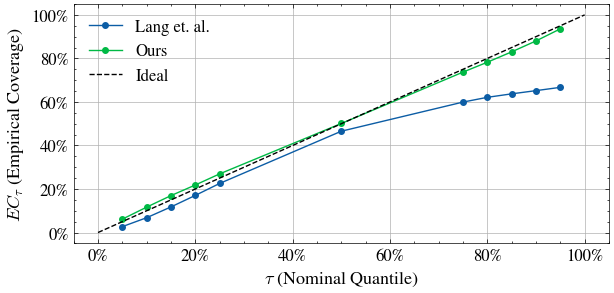

In [21]:
fig = create_empirical_coverage_plot(model_names, quantiles_sorted, displayed_model_names = displayed_model_names)
fig.savefig('results/empirical_coverage_plot.pdf', dpi=300)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Model w/o shift loss coverages: [0.503794547993443, 0.052820108068726855, 0.10491166292271265, 0.1570234553659968, 0.208467407362435, 0.2597494586444863, 0.7500657721652196, 0.7988181247849756, 0.847934754012102, 0.8970918584178252, 0.948900087021634]


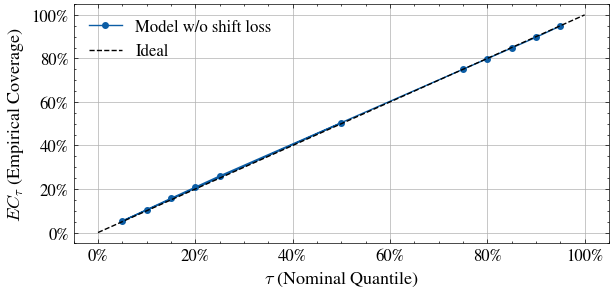

In [14]:
fig = create_empirical_coverage_plot(model_names = ['ours_wo_shift'], 
                                     quantiles_sorted = quantiles, 
                                     displayed_model_names = ['Model w/o shift loss'])
fig.savefig('results/empirical_coverage_plot_wo_shift.pdf', dpi=300)

In [8]:
def create_empirical_coverage_per_target_bin(model_name, quantiles_sorted, target_col = 'gedi_data', year=None):
    df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
    if year is not None:
        df = df[df['year'] == year]
    quantile_cols = [f'quantile_{q}' for q in quantiles_sorted]
    quantile_emp_columns = [f'{q} > {target_col}' for q in quantile_cols]
    df[quantile_emp_columns] = df[quantile_cols] > df[target_col].values[:, None]
    df['target_bin'] = pd.cut(df[target_col], bins=[0,5,10,15,20,25,30,100], right=False)
    temp = df.groupby('target_bin')[quantile_emp_columns].mean().reset_index()

    colors = plt.cm.Greens(np.linspace(0.3, 1, len(temp)))
    plt.rcParams.update({'font.size': 12})
    fig = plt.figure(figsize=(6.4, 3.2))
    for i, row in temp.iterrows():
        empirical = row[quantile_emp_columns].values
        plt.plot(quantiles_sorted, empirical, marker='o', label=str(row['target_bin']), color=colors[i], lw = 1, markersize=4)
    empirical = df[quantile_emp_columns].mean().values
    plt.plot(quantiles_sorted, empirical, marker='o', label='Overall', color='black', linewidth=1, markersize=4)
    plt.plot([0, 1], [0, 1], 'k--', lw = 1)
    plt.xticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.yticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.xlabel('$\\tau$ (Nominal Quantile)', fontdict={'size': 13})
    plt.ylabel('$EC_\\tau$ (Empirical Coverage)', fontdict={'size': 13})
    plt.legend(title='Target Bin', loc ='upper left', fontsize=9, title_fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    return fig

In [9]:
def create_empirical_coverage_per_prediction_bin(model_name, quantiles_sorted, target_col = 'gedi_data', year=None):
    df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
    if year is not None:
        df = df[df['year'] == year]
    quantile_cols = [f'quantile_{q}' for q in quantiles_sorted]
    quantile_emp_columns = [f'{q} > {target_col}' for q in quantile_cols]
    df[quantile_emp_columns] = df[quantile_cols] > df[target_col].values[:, None]
    df['prediction_bin'] = pd.cut(df['quantile_0.5'], bins=[0,5,10,15,20,25,30,100], right=False)
    temp = df.groupby('prediction_bin')[quantile_emp_columns].mean().reset_index()

    colors = plt.cm.Greens(np.linspace(0.3, 1, len(temp)))
    plt.rcParams.update({'font.size': 12})
    fig = plt.figure(figsize=(6.4, 3.2))
    for i, row in temp.iterrows():
        empirical = row[quantile_emp_columns].values
        plt.plot(quantiles_sorted, empirical, marker='o', label=str(row['prediction_bin']), color=colors[i], lw = 1, markersize=4)
    empirical = df[quantile_emp_columns].mean().values
    plt.plot(quantiles_sorted, empirical, marker='o', label='Overall', color='black', linewidth=1, markersize=4)
    plt.plot([0, 1], [0, 1], 'k--', lw = 1)
    plt.xticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.yticks(np.arange(0,1.1,0.2), [f'{100*x:.0f}%' for x in np.arange(0,1.1,0.2)])
    plt.xlabel('$\\tau$ (Nominal Quantile)', fontdict={'size': 13})
    plt.ylabel('$EC_\\tau$ (Empirical Coverage)', fontdict={'size': 13})
    plt.legend(title='Prediction Bin', loc ='upper left', fontsize=9, title_fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    return fig

/tmp/ipykernel_20945/300814138.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('target_bin')[quantile_emp_columns].mean().reset_index()
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


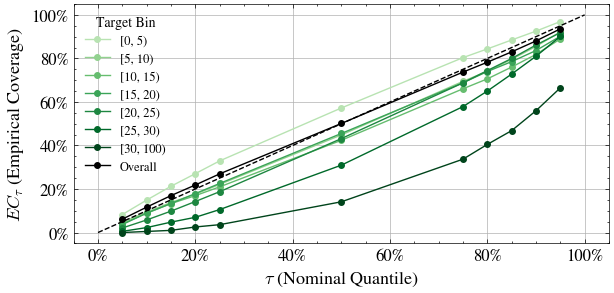

In [20]:
fig = create_empirical_coverage_per_target_bin('ours', quantiles_sorted)
fig.savefig('results/empirical_coverage_per_target_bin_ours.pdf', dpi=300)

/tmp/ipykernel_16516/300814138.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('target_bin')[quantile_emp_columns].mean().reset_index()


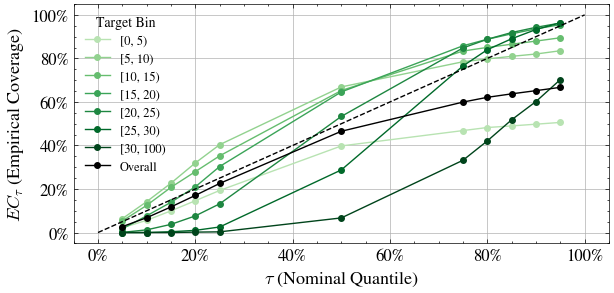

In [119]:
fig = create_empirical_coverage_per_target_bin('lang', quantiles_sorted)
# fig.savefig('results/empirical_coverage_per_target_bin_lang.pdf', dpi=300)

/tmp/ipykernel_21521/300814138.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('target_bin')[quantile_emp_columns].mean().reset_index()
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


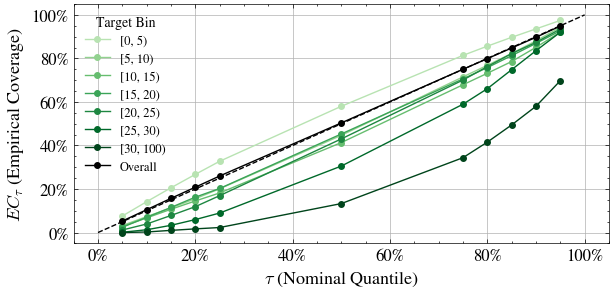

In [11]:
fig = create_empirical_coverage_per_target_bin('ours_wo_shift', quantiles_sorted)
fig.savefig('results/empirical_coverage_per_target_bin_wo_shift.pdf', dpi=300)

/tmp/ipykernel_21521/1464664041.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby('prediction_bin')[quantile_emp_columns].mean().reset_index()
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


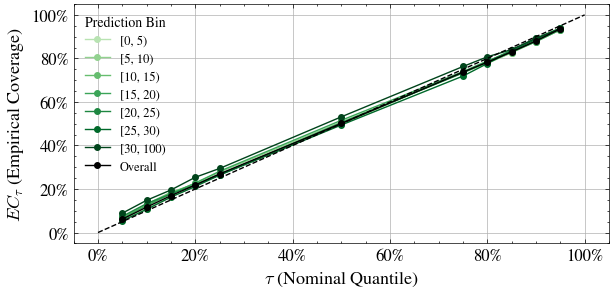

In [10]:
fig = create_empirical_coverage_per_prediction_bin('ours', quantiles_sorted)
fig.savefig('results/empirical_coverage_per_prediction_bin.pdf', dpi=300)

## Scatter Plot

In [ ]:
def create_scatter_plot(model_name, target_col='gedi_data', displayed_name=None, alpha=0.8, limit=50, vmax=20, year=None, y_label=True):
    if displayed_name is None:
        displayed_name = model_name
    print("Font family:", plt.rcParams.get('font.family'))
    print("Font size:", plt.rcParams.get('font.size'))
    plt.rcParams.update({'font.size': 14})
    fig = plt.figure(figsize=(6.4, 6.4))
    ax = fig.add_axes([0.12, 0.12, 0.70, 0.76])
    cax = fig.add_axes([0.85, 0.12, 0.03, 0.76])

    df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
    if year is not None:
        df = df[df['year'] == year]
    tau_h = round(0.5 + alpha/2, 2)
    tau_l = round(0.5 - alpha/2, 2)
    upper_pred = df[f'quantile_{tau_h}'].values
    lower_pred = df[f'quantile_{tau_l}'].values
    interval_width = np.clip(upper_pred - lower_pred, 0, vmax)
    median_pred = np.clip(df['quantile_0.5'].values, 0, limit)
    target_vals = np.clip(df[target_col].values, 0, limit)

    sc = ax.scatter(target_vals, median_pred, c=interval_width, alpha=1, label=displayed_name,
                    cmap='Reds', s=5, vmin=0, vmax=vmax)
    ax.plot([0, limit], [0, limit], 'k--', lw=1)
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel('GEDI height (m)', fontdict={'size': 15})
    ax.grid()

    if y_label:
        ax.set_ylabel('Predicted height (m)', fontdict={'size': 15})
        cax.set_visible(False)
    else:
        fig.colorbar(sc, cax=cax, label='PIW$_{\\mathrm{0.8}}$ (m)')

    return fig

Font family: ['serif']
Font size: 12.0


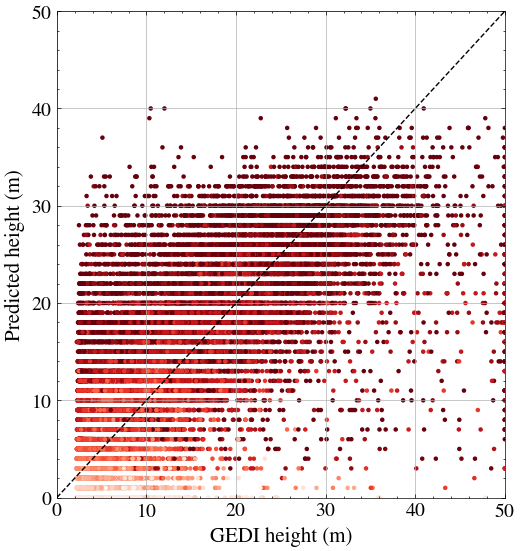

In [123]:
fig = create_scatter_plot(model_names[0], displayed_name=displayed_model_names[0], y_label=True)
# fig.savefig('results/scatter_plot_with_uncertainty_lang_new.png', dpi=300)

Font family: ['serif']
Font size: 14.0


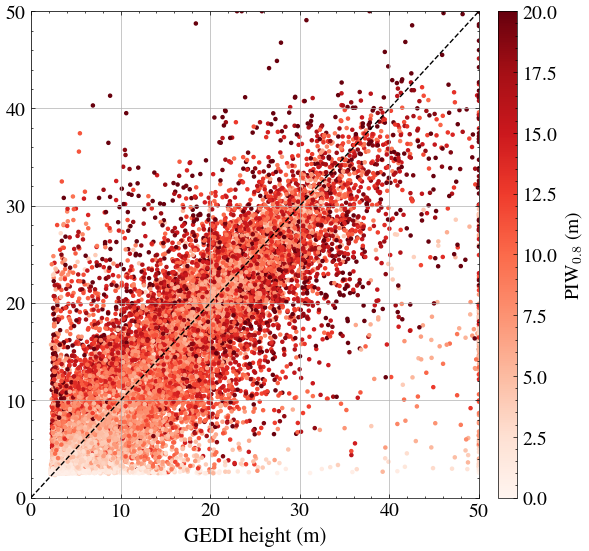

In [ ]:
fig = create_scatter_plot(model_names[1], displayed_name=displayed_model_names[1], y_label=False)
# fig.savefig('results/scatter_plot_with_uncertainty_ours_new.png', dpi=300)

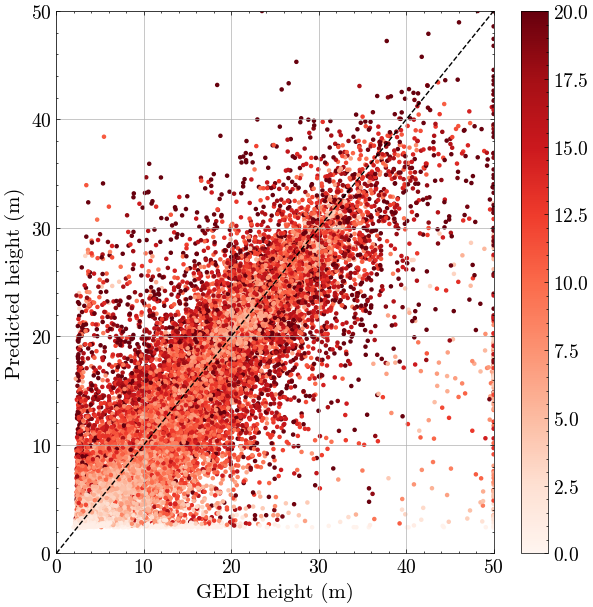

In [46]:
fig = create_scatter_plot('ours_wo_shift', displayed_name=displayed_model_names[1], y_label=True)
# fig.savefig('results/scatter_plot_with_uncertainty_wo_shift.png', dpi=300)

## MPIW, PICP Table

In [ ]:
def create_mpiw_mpic_df(model_names, quantiles_sorted, target_col = 'gedi_data', displayed_names = None, alphas = [0.5,0.6,0.7,0.8,0.9], year=None):
    if displayed_names is None:
        displayed_names = model_names
    result_df = pd.DataFrame(columns = ['name', 'alpha', 'MPIW', 'MPIC'], index = range(len(model_names)*len(alphas)))
    
    for f, (model_name, displayed_name) in enumerate(zip(model_names, displayed_names)):
        df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
        if year is not None:
            df = df[df['year'] == year]
        for g, alpha in enumerate(alphas):
            tau_h = round(0.5 + alpha/2, 2)
            tau_l = round(0.5 - alpha/2, 2)
            upper_pred = df[f'quantile_{tau_h}'].values
            lower_pred = df[f'quantile_{tau_l}'].values
            interval_width = upper_pred - lower_pred
            target_vals = df[target_col].values
            mpiw = interval_width.mean()
            mpic = ((target_vals >= lower_pred) & (target_vals <= upper_pred)).mean()
            result_df.iloc[f * len(alphas) + g] = [displayed_name, alpha, mpiw, mpic]
    result_df.iloc[:,1:] = result_df.iloc[:,1:].astype(float)
    result_df.iloc[:,1:] = result_df.iloc[:,1:].round(2)
    return result_df

def create_table_mpiw_mpic(model_names, quantiles_sorted, target_col = 'gedi_data', displayed_names = None, alphas = [0.5,0.6,0.7,0.8,0.9], year=None):
    result_df = create_mpiw_mpic_df(model_names, quantiles_sorted, target_col, displayed_names, alphas, year)
    pivot_df = result_df.pivot(index='name', columns='alpha', values=['MPIW', 'MPIC'])
    pivot_df.columns = [f'{stat}_alpha={alpha}' for stat, alpha in pivot_df.columns]
    return pivot_df

In [125]:
def pivot_df_to_latex_table(pivot_df, displayed_model_names = None):
    # Extract model names and values
    model_names = pivot_df.index.tolist()
    if displayed_model_names is None:
        displayed_model_names = model_names
    mpiw_cols = [col for col in pivot_df.columns if col.startswith('MPIW')]
    mpic_cols = [col for col in pivot_df.columns if col.startswith('MPIC')]
    alphas = [col.split('=')[1] for col in mpiw_cols]

    latex = []
    latex.append("\\begin{tabular}{r|ccccc|ccccc}")
    latex.append("\\toprule")
    latex.append("Metric & \\multicolumn{5}{c|}{MPIW} & \\multicolumn{5}{c}{MPIC} \\\\")
    latex.append(" $\\alpha$ & " + " & ".join([f"${a}$" for a in alphas]) + " & " + " & ".join([f"${a}$" for a in alphas]) + " \\\\")
    latex.append("\\midrule")
    for f, model in enumerate(model_names):
        row = [displayed_model_names[f]]
        row += [f"{pivot_df.loc[model, col]:.2f}" for col in mpiw_cols]
        row += [f"{pivot_df.loc[model, col]:.2f}" for col in mpic_cols]
        latex.append(" & ".join(row) + " \\\\")
    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    return "\n".join(latex)

In [126]:
pivot_df = create_table_mpiw_mpic(model_names+ ['ours_wo_shift'], quantiles_sorted+ ['Model w/o shift loss'], target_col = 'gedi_data', displayed_names = None, alphas = [0.5,0.6,0.7,0.8,0.9])
latex_str =  pivot_df_to_latex_table(pivot_df.round(2), displayed_model_names=displayed_model_names + ['Model w/o shift loss'])

print(latex_str)

\begin{tabular}{r|ccccc|ccccc}
\toprule
Metric & \multicolumn{5}{c|}{MPIW} & \multicolumn{5}{c}{MPIC} \\
 $\alpha$ & $0.5$ & $0.6$ & $0.7$ & $0.8$ & $0.9$ & $0.5$ & $0.6$ & $0.7$ & $0.8$ & $0.9$ \\
\midrule
Lang et. al. & 7.59 & 9.41 & 11.48 & 13.99 & 17.46 & 0.51 & 0.62 & 0.71 & 0.80 & 0.88 \\
Ours & 3.14 & 3.89 & 4.80 & 6.03 & 8.16 & 0.47 & 0.56 & 0.66 & 0.76 & 0.87 \\
Model w/o shift loss & 3.49 & 4.33 & 5.37 & 6.80 & 9.15 & 0.49 & 0.59 & 0.69 & 0.79 & 0.90 \\
\bottomrule
\end{tabular}


## Forest borders

In [5]:
import seaborn as sns
def create_border_boxenplot(model_name, year = 2020):
    df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')

    df = df[df['year'] == year]

    # Ensure quantile columns are float
    df['quantile_0.9'] = df['quantile_0.9'].astype(float)
    df['quantile_0.1'] = df['quantile_0.1'].astype(float)

    # Calculate interval width
    df['PIW_80'] = df['quantile_0.9'] - df['quantile_0.1']

    plt.rcParams.update({'font.size': 14})
    # Create boxplot grouped by forest_border
    fig = plt.figure(figsize=(6.4, 4.8))

    sns.boxenplot(y='forest_border', x='PIW_80', data=df, orient='horizontal', color='#FF4D4D')
    # plt.title('PIW_80 (quantile_0.9 - quantile_0.1) by Forest Border')
    # plt.suptitle('')
    plt.ylabel('Forest Border', fontdict={'size': 15})
    plt.xlabel('PIW$_{0.8}$ (m)', fontdict={'size': 15})
    plt.xlim(0, 50)
    plt.yticks([0, 1], ['False', 'True'])
    plt.grid(True, axis='x')
    plt.tight_layout()
    return fig

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


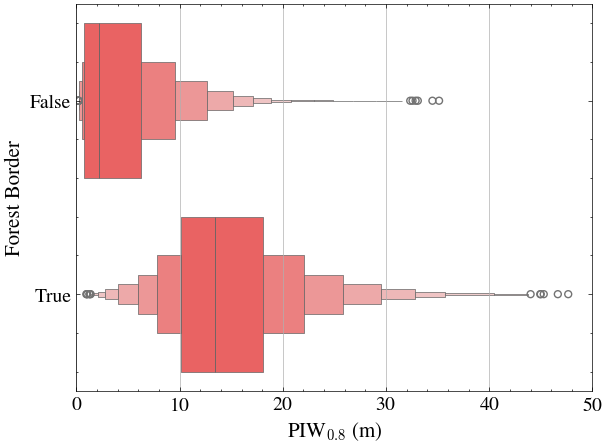

In [6]:
fig = create_border_boxenplot('ours')
plt.savefig('results/boxenplot_piw_forest_border.pdf', dpi=300)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


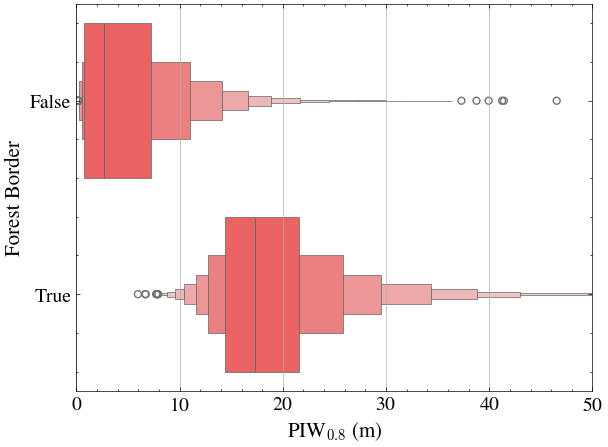

In [15]:
fig = create_border_boxenplot('ours_wo_shift')
plt.savefig('results/boxenplot_piw_forest_border_wo_shift.pdf', dpi=300)

## Scatter plot Point Estimate vs Prediction Interval Width

In [8]:
def create_scatter_plot_point_vs_piw(model_name, target_col='gedi_data', displayed_name=None, alpha=0.8, limit=50, vmax=100, year=None, y_label=True):
    if displayed_name is None:
        displayed_name = model_name
    print("Font family:", plt.rcParams.get('font.family'))
    print("Font size:", plt.rcParams.get('font.size'))
    plt.rcParams.update({'font.size': 14})
    fig = plt.figure(figsize=(6.4, 6.4))
    # ax = fig.add_axes([0.12, 0.12, 0.70, 0.76])
    # cax = fig.add_axes([0.85, 0.12, 0.03, 0.76])

    df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')
    print(f"Dataframe loaded for model: {model_name}, shape: {df.shape}")
    
    if year is not None:
        df = df[df['year'] == year]
    tau_h = round(0.5 + alpha/2, 2)
    tau_l = round(0.5 - alpha/2, 2)
    upper_pred = df[f'quantile_{tau_h}'].values
    lower_pred = df[f'quantile_{tau_l}'].values
    interval_width = np.clip(upper_pred - lower_pred, 0, vmax)
    median_pred = np.clip(df['quantile_0.5'].values, 0, limit)
    target_vals = np.clip(df[target_col].values, 0, limit)
    colors = plt.cm.Greens(np.linspace(0.3, 1, 7))
    color = colors[3]
    plt.scatter(median_pred, interval_width, alpha=1, label=displayed_name,s=0.5)
    # plt.plot([0, limit], [0, limit], 'k--', lw=1)
    plt.xlim(-0.5, limit)
    plt.ylim(-0.5, limit)
    plt.xlabel('Predicted height (m)', fontdict={'size': 15})
    plt.ylabel('PIW$_{\\mathrm{0.8}}$ (m)', fontdict={'size': 15})
    plt.grid()
    # if y_label:
    #     ax.set_ylabel('Predicted height (m)', fontdict={'size': 15})
    #     cax.set_visible(False)
    # else:
    #     fig.colorbar(sc, cax=cax, label='PIW$_{\\mathrm{0.8}}$ (m)')
    return fig, df

Font family: ['serif']
Font size: 10.0
Dataframe loaded for model: ours, shape: (49413, 17)


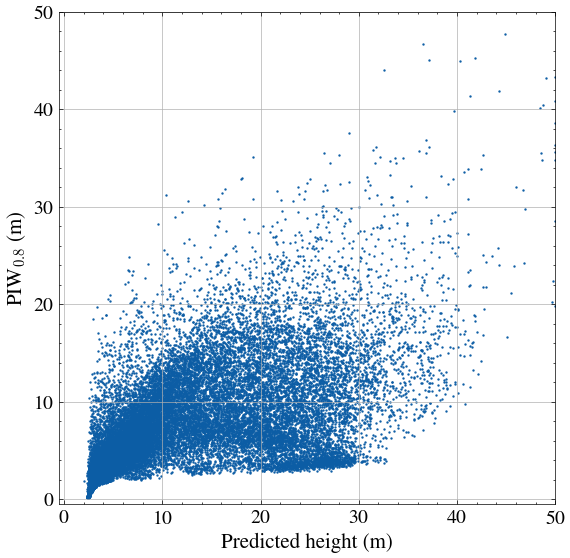

In [9]:
fig = create_scatter_plot_point_vs_piw(model_names[1], displayed_name=displayed_model_names[1], y_label=False)
# fig.savefig('results/scatter_plot_point_vs_piw_ours_new.png', dpi=300)

Font family: ['serif']
Font size: 14.0
Dataframe loaded for model: lang, shape: (49413, 16)


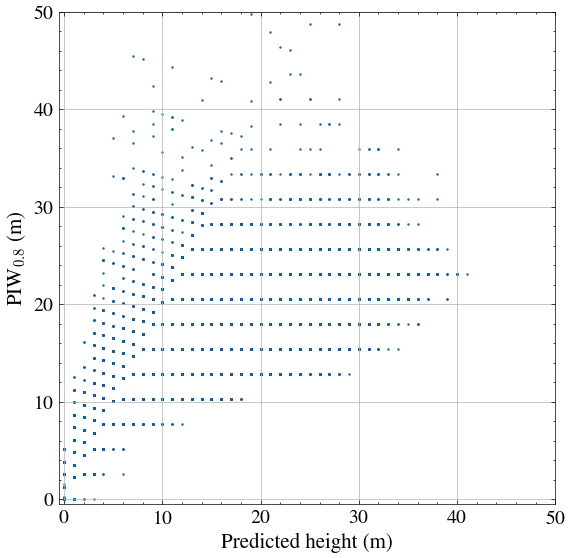

In [10]:
fig, df = create_scatter_plot_point_vs_piw(model_names[0], displayed_name=displayed_model_names[0], y_label=False)
# fig.savefig('results/scatter_plot_point_vs_piw_ours_new.png', dpi=300)

### Plot the distance from quantile predictions to median prediction

In [7]:
import seaborn as sns
model_name = model_names[1]
df = pd.read_pickle(f'results_dataframes/results_{model_name}.pkl')

In [8]:
df_boxplot = pd.DataFrame(columns=[f'{quantile}_dist_to_median' for quantile in quantiles_sorted], index=df.index)
for quantile in quantiles:
    df_boxplot[f'{quantile}_dist_to_median'] = np.abs(df[f'quantile_{quantile}'] - df[f'quantile_0.5'])


<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_23093/1507626337.py:12: SyntaxWarning: invalid escape sequence '\h'
  'bound_type': ['$ \hat{y} - \hat{y}_{low}$'] * len(diff_low) + ['$\hat{y}_{high} - \hat{y}$'] * len(diff_high),
/tmp/ipykernel_23093/1507626337.py:12: SyntaxWarning: invalid escape sequence '\h'
  'bound_type': ['$ \hat{y} - \hat{y}_{low}$'] * len(diff_low) + ['$\hat{y}_{high} - \hat{y}$'] * len(diff_high),


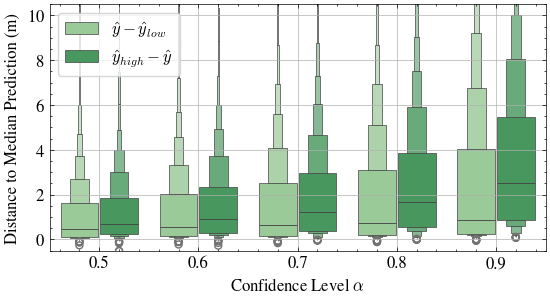

In [9]:
alphas = [0.5, 0.6, 0.7, 0.8, 0.9]
all_data = []
plt.rcParams.update({'font.size': 12})
for alpha in alphas:
    low_q = round((1 - alpha) / 2, 2)
    high_q = round(1 - low_q, 2) 
    diff_low = df['quantile_0.5'] - df[f'quantile_{low_q}']
    diff_high = df[f'quantile_{high_q}'] - df['quantile_0.5']
    
    temp_df = pd.DataFrame({
        'difference': pd.concat([diff_low, diff_high]),
        'bound_type': ['$ \hat{y} - \hat{y}_{low}$'] * len(diff_low) + ['$\hat{y}_{high} - \hat{y}$'] * len(diff_high),
        'alpha': alpha
    })
    all_data.append(temp_df)

combined_df = pd.concat(all_data)
plt.figure(figsize=(6.4,3.2))
colors = plt.cm.Greens(np.linspace(0.3, 1, 7))
color1 = colors[1]
color2 = colors[3]
# color1 = "#84F7A0"
# color2 = "#3FFA3F"

sns.boxenplot(data=combined_df, x='alpha', y='difference', hue='bound_type', palette=[color1, color2], gap = 0.05)

plt.ylim(-0.5,10.5)
legend = plt.legend(loc='upper left',frameon=True,  facecolor='white')
# legend.set_zorder(1000)
# plt.axhline(0, color='gray', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel('Confidence Level $\\alpha$')
plt.ylabel('Distance to Median Prediction (m)')
plt.grid(True)

# plt.title('Distances to Median for Different Alphas')
# plt.savefig('results/quantile_dist_to_median_boxenplot.pdf', dpi=300, bbox_inches='tight')
plt.show()